In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [104]:
df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')

In [105]:
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class


In [106]:
# Reduce to 11 of the 53 columns
a = df[['Order Country', 'Order City', 'Latitude', 'Longitude', 
    'Customer Street', 'Customer State', 'Customer Zipcode',
    'Delivery Status', 
    'Days for shipment (scheduled)',
    'Days for shipping (real)',
    'shipping date (DateOrders)']]
a.tail()

,Order Country,Order City,Latitude,Longitude,Customer Street,Customer State,Customer Zipcode,Delivery Status,Days for shipment (scheduled),Days for shipping (real),shipping date (DateOrders)
180514,China,Shanghái,40.640930,-73.942711,1322 Broad Glade,NY,11207.0,Shipping on time,4,4,1/20/2016 3:40
180515,Japón,Hirakata,35.362545,-119.018700,7330 Broad Apple Moor,CA,93304.0,Late delivery,2,3,1/19/2016 1:34
180516,Australia,Adelaide,41.629959,-72.967155,97 Burning Landing,CT,6010.0,Late delivery,4,5,1/20/2016 21:00
180517,Australia,Adelaide,18.213350,-66.370575,2585 Silent Autumn Landing,PR,725.0,Advance shipping,4,3,1/18/2016 20:18
180518,India,Nagercoil,18.290380,-66.370613,697 Little Meadow,PR,725.0,Shipping on time,4,4,1/19/2016 18:54


In [107]:
# Count the number of Origin-Destination pairs
len(a[['Order Country', 'Customer State']].drop_duplicates())

3139

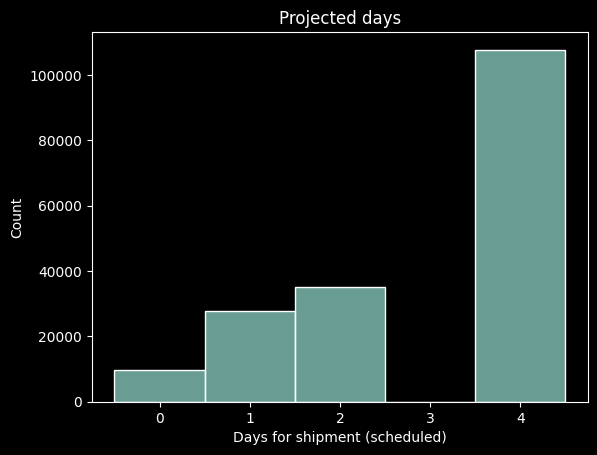

In [108]:
# Plot a histogram to instead the projected transit times
vals = a['Days for shipment (scheduled)']
# Center the histogram bars around the integer values
bins = np.arange(vals.min() - 0.5, vals.max() + 0.5 + 1e-8, 1)  # edges like -0.5,0.5,1.5,...
sns.histplot(data=a, x="Days for shipment (scheduled)", bins=bins)
plt.xticks(np.arange(vals.min(), vals.max() + 1))
plt.title('Projected days')
plt.show()

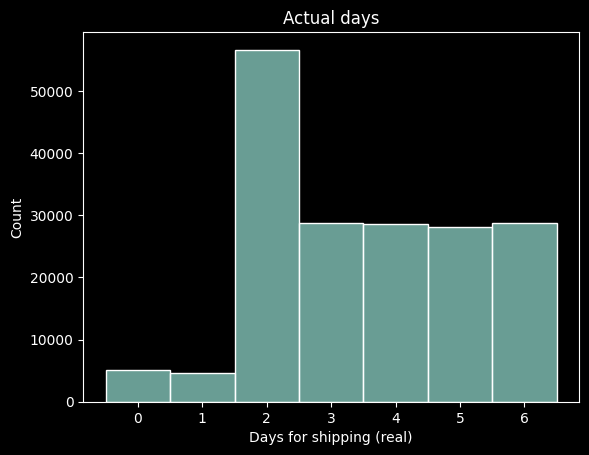

In [109]:
# Plot a histogram to instead the actual transit times
vals = a['Days for shipping (real)']
# Center the histogram bars around the integer values
bins = np.arange(vals.min() - 0.5, vals.max() + 0.5 + 1e-8, 1)  # edges like -0.5,0.5,1.5,...
sns.histplot(data=a, x="Days for shipping (real)", bins=bins)
plt.xticks(np.arange(vals.min(), vals.max() + 1))
plt.title('Actual days')
plt.show()

In [110]:
# What are the different combinations of scheduled and actual shipping days?
a.groupby(['Days for shipment (scheduled)', 'Days for shipping (real)']).count()

Order Country  \
Days for shipment (scheduled) Days for shipping (real)                  
0                             0                                  5080   
                              1                                  4657   
1                             2                                 27814   
2                             2                                  7138   
                              3                                  7065   
                              4                                  6978   
                              5                                  7052   
                              6                                  6983   
4                             2                                 21666   
                              3                                 21700   
                              4                                 21535   
                              5                                 21111   
                              6                                 21740   

                                                        Order City  Latitude  \
Days for shipment (scheduled) Days for shipping (real)                         
0                             0                               5080      5080   
                              1                               4657      4657   
1                             2                              27814     27814   
2                             2                               7138      7138   
                              3                               7065      7065   
                              4                               6978      6978   
                              5                               7052      7052   
                              6                               6983      6983   
4                             2                              21666     21666   
                              3                              21700     21700   
                              4                              21535     21535   
                              5                              21111     21111   
                              6                              21740     21740   

                                                        Longitude  \
Days for shipment (scheduled) Days for shipping (real)              
0                             0                              5080   
                              1                              4657   
1                             2                             27814   
2                             2                              7138   
                              3                              7065   
                              4                              6978   
                              5                              7052   
                              6                              6983   
4                             2                             21666   
                              3                             21700   
                              4                             21535   
                              5                             21111   
                              6                             21740   

                                                        Customer Street  \
Days for shipment (scheduled) Days for shipping (real)                    
0                             0                                    5080   
                              1                                    4657   
1                             2                                   27814   
2                             2                                    7138   
                              3                                    7065   
                              4                                    6978   
                              5                                    7052   
                              6                 

In [111]:
print(len(a['shipping date (DateOrders)'].unique())) 
print(min(a['shipping date (DateOrders)']))
print(max(a['shipping date (DateOrders)']))

63701
1/1/2016 0:22
9/9/2017 9:08


In [112]:
# Rename the columns 
a.rename(columns={
    'Order Country': 'origin_country',
    'Customer State': 'us_destination_state',
    'Customer Zipcode': 'us_destination_postal_code',
    'Delivery Status': 'delivery_status',
    'Days for shipment (scheduled)': 'projected_days',
    'Days for shipping (real)': 'actual_days',
    'shipping date (DateOrders)': 'order_date'
}, inplace=True)

In [113]:
a.tail()

,origin_country,Order City,Latitude,Longitude,Customer Street,us_destination_state,us_destination_postal_code,delivery_status,projected_days,actual_days,order_date
180514,China,Shanghái,40.640930,-73.942711,1322 Broad Glade,NY,11207.0,Shipping on time,4,4,1/20/2016 3:40
180515,Japón,Hirakata,35.362545,-119.018700,7330 Broad Apple Moor,CA,93304.0,Late delivery,2,3,1/19/2016 1:34
180516,Australia,Adelaide,41.629959,-72.967155,97 Burning Landing,CT,6010.0,Late delivery,4,5,1/20/2016 21:00
180517,Australia,Adelaide,18.213350,-66.370575,2585 Silent Autumn Landing,PR,725.0,Advance shipping,4,3,1/18/2016 20:18
180518,India,Nagercoil,18.290380,-66.370613,697 Little Meadow,PR,725.0,Shipping on time,4,4,1/19/2016 18:54


In [114]:
# Truncate the timestamps to the date (midnight) and sort by order_date
a['order_date'] = pd.to_datetime(a['order_date']).dt.normalize()
a[a['origin_country'] == 'Vietnam'].sort_values('order_date')[[
        'origin_country',
        'us_destination_state',
        'us_destination_postal_code',
        'delivery_status',
        'projected_days',
        'actual_days',
        'order_date'
]].to_parquet('../data/vietnam_to_us.parquet')